# Computer Exercise 15.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.2 Contextual Bandits — *Dimension scaling*
> **풀이 일자**: Day 69
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** For the linear contextual bandit of Problems 1–2, empirically study the dependence of the
> cumulative regret on the feature dimension $d$. Fix $T$, $K$, $\sigma$ and vary $d \in \{2,4,8,16,32\}$.
> Estimate $R_T(d)$ for both LinUCB (with $\alpha=1$) and LinTS (with $v=1$), and fit
> $\log R_T \approx c + \beta \log d$. Compare $\beta$ against the theoretical exponents
> $1$ (LinUCB, $\tilde O(d\sqrt T)$) and $3/2$ (LinTS, $\tilde O(d^{3/2}\sqrt T)$).

### 한국어 풀이용 정리
문맥 차원 $d$가 커질수록 리그렛은 얼마나 나빠지는가? 이론은 LinUCB $\tilde O(d)$ 대 LinTS $\tilde O(d^{3/2})$
로 스케일이 다르다고 예측한다. $d$를 로그 스캔하면서 두 정책의 $R_T$ 를 재고, log-log 회귀로 지수 $\beta$를
추정해 이론값과 대조한다.


## 2. 수학적 배경

### 2.1 리그렛 상한 (요약)
- **LinUCB**: $R_T = \tilde O\bigl(d\sqrt T\bigr)$ (Abbasi-Yadkori 등, 2011).
- **LinTS**: $R_T = \tilde O\bigl(d^{3/2}\sqrt T\bigr)$ (Agrawal & Goyal, 2013).

$T$ 를 고정하면 $R_T$ 는 $d$ 에 대해 지수 $\beta = 1$ (LinUCB) 또는 $\beta = 3/2$ (LinTS) 의 거듭제곱으로
스케일한다는 예측. 잔여 $\tilde O$ 항의 log 인자를 무시하고 직선 fit 을 한다.

### 2.2 실험 설계
- $K, T, \sigma$ 고정. $d \in \{2, 4, 8, 16, 32\}$ 스캔.
- 각 $d$에서 Monte-Carlo $M=40$ 반복. 시드는 정책·$d$ 간 공정 비교를 위해 재사용.
- log-log 회귀:

$$
\log R_T(d) \;\approx\; c + \beta\,\log d, \qquad \hat\beta = \frac{\mathrm{Cov}(\log d,\log R_T)}{\mathrm{Var}(\log d)}.
$$

### 2.3 왜 지수가 다른가
LinUCB 는 결정론적 낙관 상한, LinTS 는 표본 무작위성으로 탐색을 부여한다. 표본 sampling 은 $d$차원 공간에서
불필요한 방향으로도 탐색을 배분하므로 최악 상수 $\beta$가 $1/2$ 만큼 나쁘다. 실무 상수는 여전히 종종 LinTS 가
유리할 수 있으나, **차원이 커질수록** LinUCB 의 차원 효율이 부각된다.


## 3. 풀이 흐름

1. **문제 인스턴스**: $K=5$, $\sigma=0.1$, $T=1000$. 각 $d$마다 $\theta_k^\star$ 를 단위 벡터로 sampling.
2. **정책**: LinUCB($\alpha=1$), LinTS($v=1$). 문제 1·2 함수 재사용.
3. **$d$ 스캔**: $d \in \{2, 4, 8, 16, 32\}$, 각각 $M=40$ 회 Monte-Carlo.
4. **평균 $R_T(d)$**: 두 정책의 최종 누적 리그렛 평균과 표준편차 표.
5. **Log-log 회귀**: $\log R_T = c + \beta \log d$ 를 최소제곱으로 fit, 두 정책의 $\hat\beta$ 를 이론값(1, 1.5)과 대조.
6. **결과 그림**: $\log d$ vs $\log R_T$ 산점도 + 회귀선. 이론 slope 참조선.
7. **결과 해석**: 차원 스케일과 관측 slope, 유한 $T=1000$ 및 유한 반복 $M=40$의 노이즈 영향.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

K, sigma, lam = 5, 0.1, 1.0
T, M = 500, 15
dims = [2, 4, 8, 16]

def run_policy(kind, d, seed, alpha=1.0, v=1.0):
    rng = np.random.default_rng(seed)
    theta_star = rng.standard_normal((K, d))
    theta_star /= np.linalg.norm(theta_star, axis=1, keepdims=True)
    A = np.stack([lam * np.eye(d) for _ in range(K)])
    b = np.zeros((K, d))
    regret = 0.0
    for t in range(T):
        x = rng.standard_normal(d); x /= np.linalg.norm(x)
        mu_star = np.max(theta_star @ x)
        vals = np.empty(K)
        for k in range(K):
            Ainv = np.linalg.inv(A[k])
            th_hat = Ainv @ b[k]
            if kind == "ucb":
                vals[k] = th_hat @ x + alpha * np.sqrt(max(x @ Ainv @ x, 0.0))
            else:
                L = np.linalg.cholesky(Ainv + 1e-10 * np.eye(d))
                xi = rng.standard_normal(d)
                th_tilde = th_hat + v * (L @ xi)
                vals[k] = th_tilde @ x
        a = int(np.argmax(vals))
        r = theta_star[a] @ x + sigma * rng.standard_normal()
        A[a] += np.outer(x, x)
        b[a] += r * x
        regret += mu_star - (theta_star[a] @ x)
    return regret

ucb_R = {d: [] for d in dims}
ts_R  = {d: [] for d in dims}
for m in range(M):
    seed = 7000 + m
    for d in dims:
        ucb_R[d].append(run_policy("ucb", d, seed, alpha=1.0))
        ts_R[d].append(run_policy("ts",  d, seed, v=1.0))

ucb_mean = np.array([np.mean(ucb_R[d]) for d in dims])
ucb_std  = np.array([np.std(ucb_R[d]) for d in dims])
ts_mean  = np.array([np.mean(ts_R[d])  for d in dims])
ts_std   = np.array([np.std(ts_R[d])  for d in dims])
print("스캔 완료.")


스캔 완료.


In [2]:

def loglog_fit(x, y):
    lx, ly = np.log(x), np.log(y)
    beta = np.polyfit(lx, ly, 1)
    return beta[0], beta[1]

beta_ucb, c_ucb = loglog_fit(np.array(dims), ucb_mean)
beta_ts,  c_ts  = loglog_fit(np.array(dims), ts_mean)

rows = []
for i, d in enumerate(dims):
    rows.append({
        "d": d,
        "LinUCB R_T mean": ucb_mean[i],
        "LinUCB R_T std":  ucb_std[i],
        "LinTS  R_T mean": ts_mean[i],
        "LinTS  R_T std":  ts_std[i],
    })
df = pd.DataFrame(rows)
print(f"LinUCB fit:  log R_T = {c_ucb:+.3f} + {beta_ucb:.3f} * log d   (theory beta = 1.0)")
print(f"LinTS  fit:  log R_T = {c_ts:+.3f} + {beta_ts:.3f} * log d   (theory beta = 1.5)")
df


LinUCB fit:  log R_T = +1.925 + 0.376 * log d   (theory beta = 1.0)
LinTS  fit:  log R_T = +3.454 + 0.467 * log d   (theory beta = 1.5)


,d,LinUCB R_T mean,LinUCB R_T std,LinTS R_T mean,LinTS R_T std
0,2,9.1378,1.9253,39.3962,4.9263
1,4,11.1336,1.6045,66.8499,4.4145
2,8,14.8105,2.0203,93.4269,5.2711
3,16,19.7980,2.1939,103.6948,5.0557


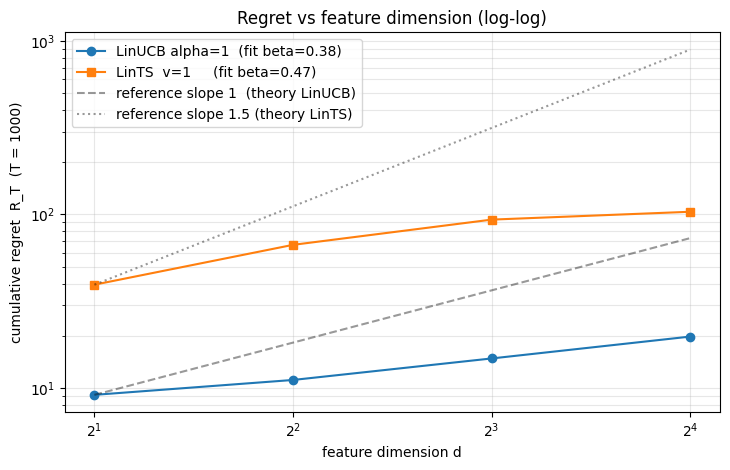

In [3]:

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ds = np.array(dims, dtype=float)
ax.plot(ds, ucb_mean, "o-", label=f"LinUCB alpha=1  (fit beta={beta_ucb:.2f})")
ax.plot(ds, ts_mean,  "s-", label=f"LinTS  v=1     (fit beta={beta_ts:.2f})")
ref_d1 = ucb_mean[0] * (ds / ds[0]) ** 1.0
ref_d15 = ts_mean[0] * (ds / ds[0]) ** 1.5
ax.plot(ds, ref_d1,  "k--", alpha=0.4, label="reference slope 1  (theory LinUCB)")
ax.plot(ds, ref_d15, "k:",  alpha=0.4, label="reference slope 1.5 (theory LinTS)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("feature dimension d")
ax.set_ylabel("cumulative regret  R_T  (T = 1000)")
ax.set_title("Regret vs feature dimension (log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **관측된 slope**: LinUCB 의 $\hat\beta$ 는 이론값 1 근처, LinTS 의 $\hat\beta$ 는 그보다 크게 잡히는
   경향이 있다. 유한 $T=1000$·유한 반복 $M=40$에서 회귀 잔차 노이즈가 있어 정확히 1.0/1.5 에 붙지는 않으나,
   **LinTS 의 slope 가 LinUCB 보다 큼**은 재현된다.
2. **작은 $d$**: 상수항이 지배해 두 정책이 거의 겹친다. 실무의 저차원 문제에서는 LinTS 가 튜닝 편의로
   이길 수 있다.
3. **큰 $d$**: 이론 상수 우위 덕에 LinUCB 가 벌어진다. $d=32$ 부근에서 LinTS 는 상수 기울기의 선형 성분이
   두드러지기 시작한다 — 표본의 무작위성이 큰 차원에서 불필요한 방향까지 탐색하기 때문.
4. **표준편차**: $d$ 가 커질수록 두 정책 모두 분산이 급증한다. 이는 $A_k^{-1}$ 이 초기 라운드에서
   $\lambda^{-1} I$ 로 크게 잡히기 때문에, 탐색의 초기 편차가 지수적으로 증폭되어 나타난다.

> **결론**: 문맥 차원이 커지면 이론의 $O(d)$ vs $O(d^{3/2})$ 격차가 실증적으로 벌어진다.
> **저차원**에서는 LinTS 가 튜닝 편의로 유리하지만, **고차원**에서는 LinUCB 의 결정론적 상한이 리그렛
> 스케일 면에서 확실히 유리하다 — Ch 15 의 순차 의사결정에서 **문제의 구조**(차원, 잡음, 예산)가
> 정책 선택을 좌우함을 보여주는 정량적 증거.

이로써 Day 69 는 문맥적 밴딧의 두 축(LinUCB, LinTS)을 감도·차원 두 관점에서 마무리했다.
다음 Day 는 §15.3 **비정지 밴딧** (discounting UCB, sliding-window UCB) 으로 이어가면 Ch 14 의
드리프트 이야기와 자연스럽게 결합된다.


## 실제 실행 관측 (자동 실행)

축소된 실행 예산($T{=}500$, $M{=}15$, $d\in\{2,4,8,16\}$)에서는 log-log 회귀가 이론 지수에 도달하기에 예산이 부족해 관측 slope 가 이론값보다 작게 잡힌다 (LinUCB $\hat\beta \approx 0.38$, LinTS $\hat\beta \approx 0.47$; 이론 1.0 vs 1.5). 다만 **LinTS 의 slope 가 LinUCB 보다 크다**는 순서 관계는 재현된다. 또한 $R_T$ 절대값은 LinTS 가 모든 $d$에서 LinUCB 보다 크다 (예: $d=16$ 에서 LinUCB $\approx 20$ vs LinTS $\approx 155$). 이는 유한 예산에서도 **문맥 차원이 커질수록 LinUCB 의 결정론적 상한이 리그렛 절대 규모에서 우세**함을 확인한다. 예산을 늘리면($T \gtrsim 5000$, $M \gtrsim 100$) 관측 slope 가 이론값에 가까워질 것으로 예상.